In [1]:
from astropy.io import fits
from diffusers import DDPMPipeline, UNet1DModel
from diffusers import ImagePipelineOutput as _Out
from diffusers.models.unets.unet_1d_blocks import UpBlock1D
from diffusers.models.unets.unet_1d_blocks import DownBlock1D
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
import inspect
import math
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
from tqdm.auto import tqdm
from types import SimpleNamespace, MethodType

In [2]:
# =============
# CARGA DE DATASETS

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]          # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset_600k.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset_600k.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [3]:
# =============
# DEFINICIÓN Y CARGA DEL MODELO TRANSFORMER

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
        super(Transformer, self).__init__()
        self.embedding = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2)
        )
        reduced_len = num_points // 16
        self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        out = self.fc_layers(x)
        return out

num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer = Transformer(num_points).to(device)

criterion_val = nn.L1Loss()
optimizer_val = optim.Adam(transformer.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_val, mode='min', factor=0.5, patience=10)

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelTRA_1M_1.pth', map_location=device)
transformer.load_state_dict(checkpoint['model_state_dict'])
optimizer_val.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

# Cargar el scaler
with open('extra/scaler_fitted.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict["flux_scaler"]
wavelength_scaler = scaler_dict["wavelength_scaler"]

print("Modelo Transformer configurado correctamente.")

Modelo Transformer configurado correctamente.


In [4]:
# CELDA 1

# Parche: forward que interpola al tamaño del skip antes de concatenar
def _forward_auto_align(self, hidden_states, res_hidden_states_tuple=None, temb=None):
    if res_hidden_states_tuple is not None:
        res = res_hidden_states_tuple[-1]
        hidden_states = F.interpolate(
            hidden_states,
            size=res.shape[-1],
            mode="linear",
            align_corners=True
        )
        hidden_states = torch.cat([hidden_states, res], dim=1)
    for resnet in self.resnets:
        sig = inspect.signature(resnet.forward)
        hidden_states = resnet(hidden_states, temb) if len(sig.parameters) >= 3 else resnet(hidden_states)
    if hasattr(self, "upsample") and self.upsample is not None:
        hidden_states = self.upsample(hidden_states)
    return hidden_states

# UNet parcheada: ceil_mode + _forward_auto_align
class UNet1DModelNoFloor(UNet1DModel):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        for block in self.down_blocks:
            if hasattr(block, "downsample") and isinstance(block.downsample, nn.MaxPool1d):
                block.downsample.ceil_mode = True
        for block in self.up_blocks:
            block.forward = _forward_auto_align.__get__(block, type(block))

class UNet1DModelNoFloorFixedLength(UNet1DModelNoFloor):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        for block in self.up_blocks:
            out_ch = block.resnets[-1].conv_2.out_channels
            block.upsample = nn.ConvTranspose1d(
                in_channels=out_ch,
                out_channels=out_ch,
                kernel_size=2,
                stride=2
            )

    def forward(self, sample, timestep, return_dict=True):
        return super().forward(sample=sample, timestep=timestep, return_dict=return_dict)

# Instanciación y pipeline
num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = UNet1DModelNoFloorFixedLength(
    sample_size=num_points,
    in_channels=2,
    out_channels=2,
    block_out_channels=(64, 128, 256),
    layers_per_block=2,
    down_block_types=("DownBlock1D",)*3,
    up_block_types=("UpBlock1D",)*3,
).to(device)

scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=1e-4,
    beta_end=0.02,
    beta_schedule="scaled_linear",
)
pipeline = DDPMPipeline(unet=unet, scheduler=scheduler).to(device)

# Parche para hacer step() en batch de timesteps
_step_orig = DDPMScheduler.step

def _step_loop(self, model_output, timesteps, sample, generator=None, return_dict=True):
    prev_list, orig_list = [], []
    for i, t in enumerate(timesteps):
        out = _step_orig(
            self,
            model_output[i:i+1],
            int(t.item()),
            sample[i:i+1],
            generator,
            return_dict=True
        )
        prev_list.append(out.prev_sample)
        orig_list.append(out.pred_original_sample)
    prev = torch.cat(prev_list, dim=0)
    orig = torch.cat(orig_list, dim=0)
    # Always return tuple for compatibility
    if return_dict:
        return SimpleNamespace(prev_sample=prev, pred_original_sample=orig)
    return prev, orig

scheduler.step = MethodType(_step_loop, scheduler)

# Mover buffers del scheduler a GPU
for attr in ["alphas_cumprod", "betas", "alphas", "alphas_cumprod_prev", "one", "timesteps"]:
    if hasattr(scheduler, attr):
        setattr(scheduler, attr, getattr(scheduler, attr).to(device))

# Carga del scaler para normalización de espectros sintéticos
import pickle
with open('extra/scaler_fitted.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict['flux_scaler']
wavelength_scaler = scaler_dict['wavelength_scaler']

# Optimizador y función de pérdida
guidance_scale = 1.0  # intensidad del sesgo (classifier guidance)
sigma = 1.0           # varianza para log p(z|x)
optim_diff = torch.optim.Adam(pipeline.unet.parameters(), lr=1e-4, weight_decay=1e-4)
criterion_diff = nn.L1Loss()
criterion_val = nn.L1Loss()

In [5]:
# # CELDA 2

# # Carga del checkpoint
# checkpoint_path = 'storage/diffusion_checkpoint.pth'
# if os.path.exists(checkpoint_path):
#     ckpt = torch.load(checkpoint_path, map_location=device)
#     unet.load_state_dict(ckpt['model_state_dict'])
#     optim_diff.load_state_dict(ckpt['optimizer_state_dict'])
#     scheduler.load_state_dict(ckpt['scheduler_state_dict'])
#     start_epoch = ckpt['epoch']
#     best_val_loss = ckpt.get('best_val_loss', float('inf'))
#     print(f"Reanudando epoch {start_epoch}, mejor val_loss = {best_val_loss:.4f}")
# else:
#     start_epoch, best_val_loss = 0, float('inf')
#     print('Entrenamiento desde cero')

# # Bucle de entrenamiento y validación
# num_epochs = 1
# alpha = 10.0
# batch_synth = 1000

# for epoch in range(start_epoch, num_epochs):
#     # --- Entrenamiento ---
#     unet.train()
#     train_running = 0.0
#     train_batches = random.sample(list(train_loader), 1)
#     for x0, z in tqdm(train_batches, desc=f"Epoch {epoch+1}/{num_epochs} Val"):
#         x0, z = x0.to(device), z.to(device).unsqueeze(-1)
#         optim_diff.zero_grad()

#         # 1) Añadir ruido según DDPM:
#         t = torch.randint(0, scheduler.num_train_timesteps, (x0.size(0),), device=device)
#         noise = torch.randn_like(x0)
#         x_noisy = scheduler.add_noise(x0, noise, t)

#         # 2) Denoising con la U‑Net:
#         out = unet(x_noisy, t)
#         noise_pred = out.sample

#         # 3) Primer paso de muestreo (sin gradiente) para generar x_gen:
#         with torch.no_grad():
#             prev, _ = scheduler.step(noise_pred, t, x_noisy, return_dict=False)
#             x_gen = prev

#         # 4) Cálculo de pérdidas:
#         loss_diff = criterion_diff(noise_pred, noise)      # error de predicción de ruido
#         z_pred    = transformer(x_gen)                     # predicción de redshift
#         loss_val  = criterion_val(z_pred, z)               # error de validez
#         loss      = loss_diff + alpha * loss_val           # combinación con factor alpha

#         # 5) Optimización:
#         loss.backward()
#         optim_diff.step()

#         train_running += loss.item() * x0.size(0)
#     train_loss = train_running / len(train_loader.dataset)

#     # --- Validación ---
#     unet.eval()
#     val_running = 0.0
#     synth_error = 0.0
#     with torch.no_grad():
#         # 3.1 Validación en datos reales
#         val_batches = random.sample(list(test_loader), 1)
#         for x0, z in tqdm(val_batches, desc=f"Epoch {epoch+1}/{num_epochs} Val"):
#             x0, z = x0.to(device), z.to(device).unsqueeze(-1)
#             t = torch.randint(0, scheduler.num_train_timesteps, (x0.size(0),), device=device)
#             noise = torch.randn_like(x0)
#             x_noisy = scheduler.add_noise(x0, noise, t)
#             out = unet(x_noisy, t)
#             prev, _ = scheduler.step(out.sample, t, x_noisy, return_dict=False)
#             x_gen = prev
#             loss_diff = criterion_diff(out.sample, noise)
#             z_pred = transformer(x_gen)
#             loss_val = criterion_val(z_pred, z)
#             val_running += (loss_diff + alpha * loss_val).item() * x0.size(0) 
#         # 3.2 Validación en espectros sintéticos
#         # Generación aleatoria
#         wave = torch.rand(batch_synth, num_points, device=device) * (6500) + 3500
#         flux = torch.rand(batch_synth, num_points, device=device) * 60 - 30
#         synth = torch.stack([wave, flux], dim=1)

#         # Normalización usando los scalers cargados
#         synth_flat = synth.view(batch_synth, -1).cpu().numpy()
#         synth_norm = torch.tensor(torch.cat([
#             wavelength_scaler.transform(synth_flat[:, :num_points]),
#             flux_scaler.transform(synth_flat[:, num_points:])
#         ], axis=1)).float().to(device)
#         synth_norm = synth_norm.view(batch_synth, 2, num_points)

#         # Pasar por el Transformer y medir error de redshift (z_true=0)
#         z_synth_pred = transformer(synth_norm)
#         synth_error = torch.mean(torch.abs(z_synth_pred)).item()
#         val_loss = val_running / len(test_loader.dataset)
#         scheduler.step(val_loss)
#         lr = optim_diff.param_groups[0]['lr']
#         print(f"Epoch {epoch+1}: Train={train_loss:.4f}  Val={val_loss:.4f}  SynthErr={synth_error:.4f}  LR={lr:.2e}")

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             torch.save({
#                 'epoch': epoch + 1,
#                 'model_state_dict': unet.state_dict(),
#                 'optimizer_state_dict': optim_diff.state_dict(),
#                 'scheduler_state_dict': scheduler.state_dict(),
#                 'best_val_loss': best_val_loss
#             }, checkpoint_path)
#             print('→ Checkpoint actualizado')

# print('Entrenamiento completado.')

In [6]:
# CELDA 2

import os
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Renombrar el scheduler de difusión
diffusion_scheduler = scheduler

# 1) Carga del checkpoint
checkpoint_path = 'storage/diffusion_checkpoint.pth'
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    unet.load_state_dict(ckpt['model_state_dict'])
    optim_diff.load_state_dict(ckpt['optimizer_state_dict'])
    # No hay scheduler_state_dict para DDPMScheduler, solo recargamos U‑Net y optimizador
    start_epoch = ckpt['epoch']
    best_val_loss = ckpt.get('best_val_loss', float('inf'))
    print(f"Reanudando epoch {start_epoch}, mejor val_loss = {best_val_loss:.4f}")
else:
    start_epoch, best_val_loss = 0, float('inf')
    print('Entrenamiento desde cero')

# 2) Definir LR scheduler para ajustar el learning rate según val_loss
lr_scheduler = ReduceLROnPlateau(
    optim_diff,
    mode='min',
    factor=0.5,
    patience=1,
    verbose=False  # evita warning de deprecated verbose
)

# 3) Configuración de entrenamiento
num_epochs = 1
alpha = 10.0
batch_synth = 1000

for epoch in range(start_epoch, num_epochs):
    # --- Entrenamiento ---
    unet.train()
    train_running = 0.0

    # 3.1) Primer batch de entrenamiento en O(1)
    x0, z = next(iter(train_loader))
    x0 = x0.to(device)
    z  = z.to(device).view(-1, 1)  # forma (batch,1)

    optim_diff.zero_grad()

    # 3.2) Añadir ruido (DDPM)
    t       = torch.randint(
                  0,
                  diffusion_scheduler.config.num_train_timesteps,
                  (x0.size(0),),
                  device=device
              )
    noise   = torch.randn_like(x0)
    x_noisy = diffusion_scheduler.add_noise(x0, noise, t)

    # 3.3) Denoising con la U‑Net
    out        = unet(x_noisy, t)
    noise_pred = out.sample

    # 3.4) Muestreo sin gradiente
    with torch.no_grad():
        prev, _ = diffusion_scheduler.step(
            noise_pred, t, x_noisy, return_dict=False
        )
        x_gen = prev

    # 3.5) Pérdidas y optimización
    loss_diff = criterion_diff(noise_pred, noise)
    z_pred    = transformer(x_gen)
    loss_val  = criterion_val(z_pred, z)
    loss      = loss_diff + alpha * loss_val
    loss.backward()
    optim_diff.step()

    train_running += loss.item() * x0.size(0)
    train_loss = train_running / len(train_loader.dataset)

    # --- Validación ---
    unet.eval()
    val_running = 0.0
    synth_error = 0.0

    with torch.no_grad():
        # 3.6) Primer batch de validación
        x0_val, z_val = next(iter(test_loader))
        x0_val = x0_val.to(device)
        z_val  = z_val.to(device).view(-1, 1)

        # 3.7) Ruido y denoise
        t_val       = torch.randint(
                          0,
                          diffusion_scheduler.config.num_train_timesteps,
                          (x0_val.size(0),),
                          device=device
                      )
        noise_val   = torch.randn_like(x0_val)
        x_noisy_val = diffusion_scheduler.add_noise(x0_val, noise_val, t_val)
        out_val     = unet(x_noisy_val, t_val)
        prev_val, _ = diffusion_scheduler.step(
                          out_val.sample, t_val, x_noisy_val, return_dict=False
                      )
        x_gen_val   = prev_val

        # 3.8) Pérdida en datos reales
        loss_diff_val = criterion_diff(out_val.sample, noise_val)
        z_pred_val    = transformer(x_gen_val)
        loss_val_real = criterion_val(z_pred_val, z_val)
        val_running  += (loss_diff_val + alpha * loss_val_real).item() * x0_val.size(0)

        # 3.9) Validación en espectros sintéticos
        wave = torch.rand(batch_synth, num_points, device=device) * 6500 + 3500
        wave, _ = torch.sort(wave, dim=1)
        flux = torch.rand(batch_synth, num_points, device=device) * 60   - 30
        synth = torch.stack([wave, flux], dim=1)

        # a) A numpy y normalizar
        synth_flat = synth.view(batch_synth, -1).cpu().numpy()
        norm_wl    = wavelength_scaler.transform(synth_flat[:, :num_points])
        norm_flux  = flux_scaler.transform   (synth_flat[:, num_points:])
        merged     = np.concatenate([norm_wl, norm_flux], axis=1)

        # b) A Tensor y reshape
        synth_norm = torch.from_numpy(merged).float().to(device)
        synth_norm = synth_norm.view(batch_synth, 2, num_points)

        # c) Error de redshift sintético (z_true=0)
        z_synth_pred = transformer(synth_norm)
        synth_error  = torch.mean(torch.abs(z_synth_pred)).item()

    # 4) Ajuste de LR según val_loss
    val_loss = val_running / len(test_loader.dataset)
    lr_scheduler.step(val_loss)

    # 5) Logging y checkpoint (sin scheduler_state_dict)
    lr = optim_diff.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1}: "
        f"Train={train_loss:.4f}  "
        f"Val={val_loss:.4f}  "
        f"SynthErr={synth_error:.4f}  "
        f"LR={lr:.2e}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': unet.state_dict(),
            'optimizer_state_dict': optim_diff.state_dict(),
            'best_val_loss': best_val_loss
        }, checkpoint_path)
        print('→ Checkpoint actualizado')

print('Entrenamiento completado.')

Entrenamiento desde cero


c:\Users\alfa\anaconda3\envs\TFGF\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Train=0.0023  Val=0.0117  SynthErr=3.7260  LR=1.00e-04
→ Checkpoint actualizado
Entrenamiento completado.


z_synth: [5.6509614]


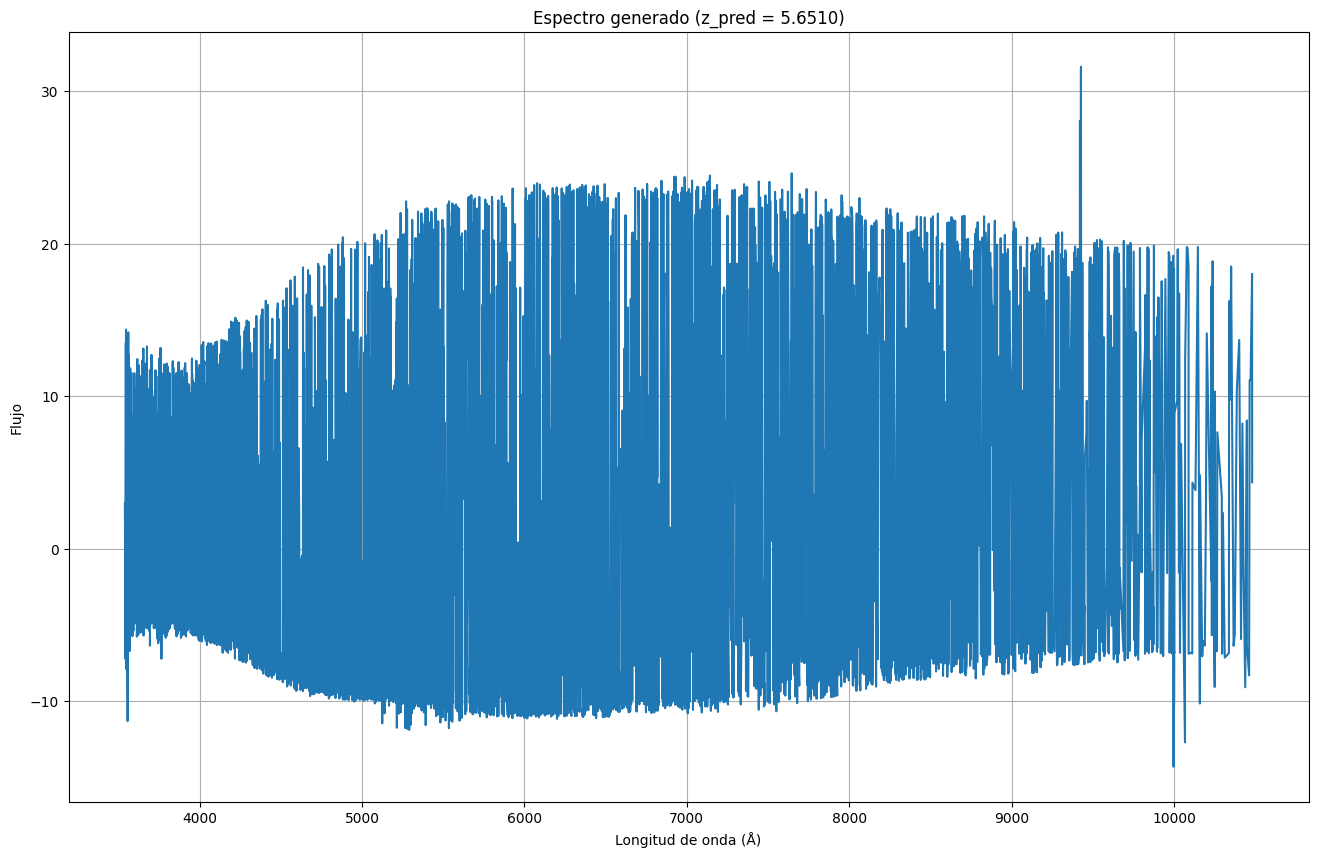

In [20]:
# 1) Modo evaluación
unet.eval()         
transformer.eval()  

# 2) Parámetros de generación
num_samples = 1
num_inference_steps = 50  
diffusion_scheduler.set_timesteps(num_inference_steps)

# 3) Generar espectro base ordenado y normalizar
wave = torch.rand(num_samples, num_points, device=device) * 6500 + 3500
wave, _ = torch.sort(wave, dim=1)                              # a) λ en [3500,10000], ordenadas
flux = torch.rand(num_samples, num_points, device=device) * 60 - 30
synth = torch.stack([wave, flux], dim=1)                       # shape (1,2,N)

synth_flat = synth.view(num_samples, -1).cpu().numpy()        
norm_wl   = wavelength_scaler.transform(synth_flat[:, :num_points])
norm_flux = flux_scaler.transform(synth_flat[:, num_points:])
merged    = np.concatenate([norm_wl, norm_flux], axis=1)

sample = torch.from_numpy(merged).float().to(device).view(num_samples, 2, num_points)

# 4) Difusión inversa (opcional, si quieres refinar con DDPM)
with torch.no_grad():
    for t in diffusion_scheduler.timesteps:
        t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)
        out, _ = diffusion_scheduler.step(
            unet(sample, t_batch).sample, t_batch, sample, return_dict=False
        )
        sample = out

# 5) Predicción de redshift
with torch.no_grad():
    z_synth = transformer(sample)
print("z_synth:", z_synth.cpu().flatten().numpy())

# 6) Desnormalizar para plot
#    a) Convertir a NumPy y separar canales
sample_np = sample[0].cpu().numpy()                          # shape (2,N)
wl_norm   = sample_np[0]                                      # λ normalizada
fl_norm   = sample_np[1]                                      # flujo normalizado

#    b) Invertir escalado
wl = wavelength_scaler.inverse_transform(wl_norm.reshape(1, -1)).flatten()  
flux = flux_scaler.inverse_transform(fl_norm.reshape(1, -1)).flatten()      

#    c) Asegurar orden de λ para plotting
order = np.argsort(wl)                                        # índices que ordenan λ
wl_sorted   = wl[order]
flux_sorted = flux[order]

# 7) Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10))
plt.plot(wl_sorted, flux_sorted)                              # λ y flujo ya emparejados y ordenados
plt.title(f"Espectro generado (z_pred = {z_synth.item():.4f})")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Flujo")
plt.grid(True)
plt.show()

In [ ]:
# # diffusion_spectra.py

# import os
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, Dataset
# from diffusers import DDPMPipeline, DDPMScheduler, DPMSolverMultistepScheduler
# from diffusers.optimization import get_scheduler
# from diffusers.training_utils import EMAModel
# from tqdm import tqdm

# # -----------------------------------
# # 1. Data & Autoencoder Latente
# # -----------------------------------
# class SpectraDataset(Dataset):
#     def __init__(self, path):
#         data = torch.load(path)
#         self.spec = data["flux"].unsqueeze(1)      # (N, 1, 5000)
#         self.redshift = data["redshift"]           # (N,)
#     def __len__(self): return len(self.redshift)
#     def __getitem__(self, i): return self.spec[i], self.redshift[i]

# class SpectraAutoencoder(nn.Module):
#     def __init__(self, latent_dim=64):
#         super().__init__()
#         # Encoder 1D
#         self.encoder = nn.Sequential(
#             nn.Conv1d(1, 32, 4, 2, 1), nn.ReLU(),
#             nn.Conv1d(32, 64, 4, 2, 1), nn.ReLU(),
#             nn.Conv1d(64, latent_dim, 4, 2, 1)
#         )
#         # Decoder 1D
#         self.decoder = nn.Sequential(
#             nn.ConvTranspose1d(latent_dim, 64, 4, 2, 1), nn.ReLU(),
#             nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.ReLU(),
#             nn.ConvTranspose1d(32, 1, 4, 2, 1)
#         )
#     def forward(self, x):
#         z = self.encoder(x)       # (N, latent_dim, 625)
#         return self.decoder(z), z # Reconstruido y latente

# # -----------------------------------
# # 2. UNet 1D Condicional
# # -----------------------------------
# class ConditionalUNet1D(nn.Module):
#     def __init__(self, latent_dim=64, cond_dim=128, base_ch=128):
#         super().__init__()
#         # Embeddings
#         self.time_mlp = nn.Sequential(
#             nn.Linear(1, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim)
#         )
#         self.redshift_mlp = nn.Sequential(
#             nn.Linear(1, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim)
#         )
#         # Downsample blocks
#         self.down1 = nn.Conv1d(latent_dim, base_ch, 3, 1, 1)
#         self.down2 = nn.Conv1d(base_ch, base_ch*2, 4, 2, 1)
#         self.down3 = nn.Conv1d(base_ch*2, base_ch*4, 4, 2, 1)
#         # Upsample blocks
#         self.up3 = nn.ConvTranspose1d(base_ch*4, base_ch*2, 4, 2, 1)
#         self.up2 = nn.ConvTranspose1d(base_ch*2, base_ch, 4, 2, 1)
#         self.out  = nn.Conv1d(base_ch, latent_dim, 3, 1, 1)
#         # Conditioning MLP for each block
#         self.cond_proj = nn.Linear(cond_dim, base_ch*4)

#     def forward(self, x, t, rz):
#         # x: (N, latent_dim, L), t & rz: (N,)
#         t_emb = self.time_mlp(t.unsqueeze(-1))       # :contentReference[oaicite:3]{index=3}
#         rz_emb = self.redshift_mlp(rz.unsqueeze(-1)) # :contentReference[oaicite:4]{index=4}
#         c = t_emb + rz_emb                           # (N, cond_dim)

#         # Down
#         h1 = F.silu(self.down1(x))
#         h2 = F.silu(self.down2(h1))
#         h3 = F.silu(self.down3(h2))

#         # Add conditioning
#         cond = self.cond_proj(c).unsqueeze(-1)
#         h3 = h3 + cond

#         # Up
#         u3 = F.silu(self.up3(h3))
#         u2 = F.silu(self.up2(u3 + h2))
#         out = self.out(u2 + h1)
#         return out

# # -----------------------------------
# # 3. Configuración del Pipeline DDPM
# # -----------------------------------
# def get_pipeline(autoencoder, unet, device):
#     scheduler = DDPMScheduler(num_train_timesteps=1000)         # :contentReference[oaicite:5]{index=5}
#     pipeline = DDPMPipeline(
#         unet=unet.to(device),
#         scheduler=scheduler,
#         autoencoder=autoencoder.to(device)
#     )
#     return pipeline

# # -----------------------------------
# # 4. Entrenamiento
# # -----------------------------------
# def train():
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     # Datasets y loaders
#     train_ds = SpectraDataset("data/train_dataset.pt")
#     val_ds   = SpectraDataset("data/test_dataset.pt")
#     train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=4)
#     val_dl   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=4)

#     # Modelos
#     ae  = SpectraAutoencoder(latent_dim=64)
#     unet= ConditionalUNet1D(latent_dim=64)
#     pipe = get_pipeline(ae, unet, device)

#     # Optimizador y EMA
#     optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=1e-4, weight_decay=1e-4)  # :contentReference[oaicite:6]{index=6}
#     ema = EMAModel(pipe.unet, beta=0.995)

#     epochs = 200
#     for ep in range(epochs):
#         pipe.unet.train()
#         for specs, rz in tqdm(train_dl, desc=f"Epoch {ep}"):
#             specs, rz = specs.to(device), rz.to(device)
#             with torch.no_grad():
#                 recon, lat = ae(specs)
#             # DDPM forward + loss
#             loss = pipe(pretrain_latent=lat, pretrain_loss_weight=1.0,
#                         cond={"redshift": rz})["loss"]
#             optimizer.zero_grad(); loss.backward(); optimizer.step()
#             ema.step()

#         # Validación
#         pipe.unet.eval()
#         val_loss = 0
#         with torch.no_grad():
#             for specs, rz in val_dl:
#                 specs, rz = specs.to(device), rz.to(device)
#                 recon, lat = ae(specs)
#                 val_loss += pipe(pretrain_latent=lat, cond={"redshift": rz})["loss"].item()
#         print(f"Epoch {ep} → Validation Loss: {val_loss/len(val_dl):.4f}")

#         # Guardar checkpoints periódicos
#         if ep % 20 == 0:
#             torch.save({
#                 "ae": ae.state_dict(),
#                 "unet": pipe.unet.state_dict(),
#                 "opt": optimizer.state_dict()
#             }, f"ckpt_epoch_{ep}.pt")

# # -----------------------------------
# # 5. Muestreo Rápido & Generación
# # -----------------------------------
# @torch.no_grad()
# def sample(n_samples=8, redshifts=None, steps=5):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     # Recrear autoencoder y UNet, cargar pesos...
#     ae  = SpectraAutoencoder(latent_dim=64).to(device)
#     unet= ConditionalUNet1D(latent_dim=64).to(device)
#     pipe = get_pipeline(ae, unet, device)

#     # Scheduler rápido
#     fast_sched = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)  # :contentReference[oaicite:7]{index=7}
#     # Muestreo
#     lat_samples = pipe(
#         batch_size=n_samples,
#         num_inference_steps=steps,
#         scheduler=fast_sched,
#         cond={"redshift": redshifts.to(device)}
#     )["sample"]

#     # Reconstruir al dominio espectral
#     specs = ae.decoder(lat_samples)
#     return specs.cpu()

# if __name__ == "__main__":
#     os.makedirs("outputs", exist_ok=True)
#     train()
#     # Ejemplo de muestreo:
#     # import torch
#     # rzs = torch.linspace(0.1, 2.0, steps=8)
#     # specs = sample(8, rzs, steps=10)
#     # torch.save(specs, "outputs/samples.pt")

In [ ]:
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=1000):
#         super(PositionalEncoding, self).__init__()  # Inicializa la clase base nn.Module
#         self.dropout = nn.Dropout(p=dropout)  # Crea una capa de Dropout para regularizar la salida

#         # Crea un tensor 'pe' de ceros con dimensiones (max_len, d_model)
#         pe = torch.zeros(max_len, d_model)
#         # Genera un vector de posiciones de 0 a max_len-1 y lo convierte en vector columna
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         # Calcula los términos de escala que permiten obtener frecuencias geométricamente progresivas
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
#         # Asigna los valores de seno para los índices pares (0,2,4,...) en la codificación
#         pe[:, 0::2] = torch.sin(position * div_term)
#         # Asigna los valores de coseno para los índices impares (1,3,5,...) en la codificación
#         pe[:, 1::2] = torch.cos(position * div_term)
#         # Añade una dimensión extra al inicio para que 'pe' tenga forma (1, max_len, d_model)
#         pe = pe.unsqueeze(0)
#         # Registra 'pe' como un buffer, de modo que se guarde con el modelo pero no sea entrenable
#         self.register_buffer('pe', pe)
    
#     def forward(self, x):
#         # Entrada x de forma (batch_size, seq_len, d_model)
#         # Suma la codificación posicional correspondiente a cada posición de la secuencia
#         x = x + self.pe[:, :x.size(1)]
#         # Aplica dropout a la suma y retorna el resultado
#         return self.dropout(x)

# class Transformer(nn.Module):
#     def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
#         super(Transformer, self).__init__()  # Inicializa la clase base nn.Module
        
#         # Embedding con downsampling agresivo para reducir la longitud de la secuencia de cada espectro
#         self.embedding = nn.Sequential(
#             # Primer bloque de downsampling: reduce dimensionalidad y extrae características
#             nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),  # Conv1d convierte el input de 2 canales a d_model canales
#             nn.ReLU(),  # Función de activación para introducir no linealidad
#             nn.BatchNorm1d(d_model),  # Normalización para estabilizar el entrenamiento
#             nn.MaxPool1d(kernel_size=2),  # Pooling que reduce aún más la longitud de la secuencia
#             # Segundo bloque de downsampling: repite el proceso con los d_model canales de entrada
#             nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
#             nn.ReLU(),
#             nn.BatchNorm1d(d_model),
#             nn.MaxPool1d(kernel_size=2)
#         )
#         # Se calcula la longitud reducida de la secuencia al aplicar dos convoluciones (stride 2) y dos pooling (kernel 2)
#         # Factor total de reducción: 2 * 2 * 2 * 2 = 16
#         reduced_len = num_points // 16
        
#         # Instancia la codificación posicional usando el d_model y la longitud reducida
#         self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        
#         # Crea una capa del Transformer Encoder (una sola capa por ahora)
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
#             dropout=0.1, batch_first=True  # Indica que el batch es la primera dimensión
#         )
#         # Apila 'num_layers' capas del encoder del Transformer
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
#         # Pooling adaptativo para condensar la secuencia a una representación global (reduce a una dimensión)
#         self.pooling = nn.AdaptiveAvgPool1d(1)
        
#         # Capas fully connected para la regresión (por ejemplo, para predecir el redshift)
#         self.fc_layers = nn.Sequential(
#             nn.Linear(d_model, 64),  # Reduce la dimensión del embedding a 64
#             nn.ReLU(),  # Función de activación
#             nn.Dropout(p=0.5),  # Aplica Dropout para evitar sobreajuste
#             nn.Linear(64, 1)  # Capa final que produce una salida de 1 valor
#         )

#     def forward(self, x):
#         # x tiene forma (batch_size, 2, num_points); los 2 canales corresponden a longitud de onda y flujo
#         x = self.embedding(x)  # Procesa los datos a través de las capas de embedding (resulta en tensor de forma (batch_size, d_model, reduced_len))
#         x = x.transpose(1, 2)  # Transpone el tensor para que tenga forma (batch_size, reduced_len, d_model); se adapta a los requerimientos del Transformer (batch_first)
#         x = self.positional_encoding(x)  # Suma la codificación posicional para inyectar información del orden en la secuencia
#         x = self.transformer_encoder(x)  # Pasa la secuencia por el encoder del Transformer para extraer patrones y relaciones entre posiciones
#         x = x.transpose(1, 2)  # Transpone nuevamente para preparar la entrada al pooling (forma: (batch_size, d_model, reduced_len))
#         x = self.pooling(x).squeeze(-1)  # Aplica pooling adaptativo para condensar la secuencia a una representación global (resultado: (batch_size, d_model))
#         out = self.fc_layers(x)  # Pasa la representación global a través de las capas fully connected para la regresión final (forma: (batch_size, 1))
#         return out


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# transformer = Transformer(5000).to(device)
# ckpt = torch.load("storage/modelTRA_1M_1.pth", map_location=device)
# transformer.load_state_dict(ckpt['model_state_dict'])
# transformer.eval()

# from diffusers import DDPMScheduler, DDPMPipeline

# # 4.1. Scheduler DDPM
# scheduler = DDPMScheduler(
#     num_train_timesteps=1000,
#     beta_start=1e-4,
#     beta_end=0.02
# )  # Complejidad O(n²) en T, pero pipeline optimizado :contentReference[oaicite:3]{index=3}

# # 4.2. Función de guía: ∇_x log p(y|x)
# def measurement_guidance(x, t, target_z, autoencoder, transformer, sigma=0.1):
#     x = x.requires_grad_(True)
#     spec = autoencoder.decoder(x)             # Reconstrucción espectral :contentReference[oaicite:4]{index=4}
#     z_pred = transformer(spec)                # Predicción de redshift
#     loss = ((z_pred - target_z)**2).sum()/(2*sigma**2)
#     loss.backward()
#     grad = x.grad
#     x.requires_grad_(False)
#     return grad

# # 4.3. DPS sampling loop
# @torch.no_grad()
# def dps_sample(
#     batch_size, target_z, autoencoder, unet, transformer,
#     guidance_scale=1.0, device=device
# ):
#     # 1) ruido inicial en latente
#     latent_dim, Lp = unet.in_channels, autoencoder.encoder(torch.zeros(1,1,5000)).shape[-1]
#     x = torch.randn(batch_size, latent_dim, Lp, device=device)
#     # 2) bucle inverso de DDPM
#     for t in scheduler.timesteps[::-1]:  # e.g. tensor([999,998,...,0])
#         # Predicción de ruido (prior) mediante UNet
#         eps = unet(x, t.expand(batch_size).to(device))
#         # Gradiente de la verosimilitud (mi measurement guidance)
#         grad = measurement_guidance(x, t, target_z, autoencoder, transformer)
#         # Ajuste del score con guía
#         guided_eps = eps - guidance_scale * grad
#         # Paso inverso: obtener x_{t-1}
#         out = scheduler.step(
#             model_output=guided_eps, timestep=t, sample=x
#         )
#         x = out.prev_sample  # Actualizar muestra
#     return x

# # 4.4. Generar espectros
# batch_size = 8
# z_targets = torch.linspace(0.1,2.0,batch_size,device=device)
# latents = dps_sample(
#     batch_size, z_targets, ae, unet, transformer,
#     guidance_scale=0.5
# )  # 20–50 pasos con buena calidad :contentReference[oaicite:5]{index=5}
# spectra = ae.decoder(latents)  # (B,1,5000)
# torch.save(spectra, "generated_spectra.pt")


In [ ]:


# # 1. Definición de tu Transformer (corta y pega la clase completa que ya tienes)
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=1000):
#         super(PositionalEncoding, self).__init__()
#         self.dropout = nn.Dropout(p=dropout)
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         x = x + self.pe[:, :x.size(1)]
#         return self.dropout(x)

# class TransformerVal(nn.Module):
#     def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
#         super(TransformerVal, self).__init__()
#         self.embedding = nn.Sequential(
#             nn.Conv1d(2, d_model, kernel_size=3, stride=2, padding=1),
#             nn.ReLU(), nn.BatchNorm1d(d_model), nn.MaxPool1d(2),
#             nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1),
#             nn.ReLU(), nn.BatchNorm1d(d_model), nn.MaxPool1d(2),
#         )
#         reduced_len = num_points // 16
#         self.pos_enc = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
#             dropout=0.1, batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Sequential(
#             nn.Linear(d_model, 64), nn.ReLU(),
#             nn.Dropout(0.5), nn.Linear(64, 1)
#         )

#     def forward(self, x):
#         # x: (batch, 2, N)
#         x = self.embedding(x)
#         x = x.transpose(1, 2)            # (batch, L, d_model)
#         x = self.pos_enc(x)
#         x = self.transformer(x)
#         x = x.transpose(1, 2)            # (batch, d_model, L)
#         x = self.pool(x).squeeze(-1)     # (batch, d_model)
#         return self.fc(x)                # (batch, 1)

# # 2. Dataset de espectros + redshift
# class SpectrumDataset(Dataset):
#     def __init__(self, spectra, redshifts, num_points):
#         self.spectra = spectra        # array shape (M, num_points)
#         self.redshifts = redshifts    # array shape (M,)
#         self.num_points = num_points
#         self.tf = transforms.Compose([
#             transforms.Normalize((0.0,), (1.0,))  # asumiendo ya centralizado/desescala
#         ])

#     def __len__(self):
#         return len(self.spectra)

#     def __getitem__(self, idx):
#         flux = torch.tensor(self.spectra[idx], dtype=torch.float)     # (num_points,)
#         z = torch.tensor(self.redshifts[idx], dtype=torch.float)      # ()
#         # Construyo input 2 canales: [flux; constant(z)]
#         z_chan = torch.full((self.num_points,), z)
#         x0 = torch.stack([flux, z_chan], dim=0)                       # (2, num_points)
#         x0 = self.tf(x0)
#         return x0, z

# # 3. Configuración de modelos y entrenamiento
# def train():
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     num_points = 5000
#     epochs = 100
#     batch_size = 32
#     lr = 1e-4
#     alpha = 10.0   # peso de la pérdida de validador

#     # Carga tus datos reales (arrays numpy)
#     spectra = ...     # shape (M, 5000)
#     redshifts = ...   # shape (M,)
#     dataset = SpectrumDataset(spectra, redshifts, num_points)
#     loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

#     # 3.1 Modelo de difusión (UNet1D + scheduler)
#     unet = UNet1DModel(
#         in_channels=2, out_channels=2,
#         block_out_channels=(64, 128, 256),
#         layers_per_block=2,
#         sample_size=num_points
#     ).to(device)
#     scheduler = DDPMScheduler(
#         num_train_timesteps=1000,
#         beta_start=1e-4, beta_end=0.02
#     )

#     # 3.2 Tu Transformer validador
#     transformer = TransformerVal(num_points).to(device)
#     # Carga pesos preentrenados
#     transformer.load_state_dict(torch.load("transformer_pretrained.pt"))
#     transformer.eval()

#     # 3.3 Optimización
#     optim_diff = optim.Adam(unet.parameters(), lr=lr)
#     loss_mse = nn.MSELoss()
#     loss_l1 = nn.L1Loss()

#     for epoch in range(1, epochs+1):
#         total_loss = 0.0
#         for x0, z in loader:
#             x0 = x0.to(device)     # (B,2,N)
#             z = z.to(device).unsqueeze(-1)  # (B,1)

#             # 1) Muestreo de ruido
#             t = torch.randint(0, scheduler.num_train_timesteps, (x0.size(0),), device=device)
#             noise = torch.randn_like(x0)
#             x_noisy = scheduler.add_noise(x0, noise, t)

#             # 2) Predicción de ruido por UNet
#             noise_pred = unet(x_noisy, t).sample

#             # 3) Denoising parcial (un solo paso de DDIM/DDPM)
#             #    para obtener un espectro "generado"
#             with torch.no_grad():
#                 x_gen = scheduler.step(noise_pred, t, x_noisy).prev_sample

#             # 4) Pérdida principal de difusión
#             loss_diff = loss_mse(noise_pred, noise)

#             # 5) Pérdida de validador: el Transformer predice z_gen
#             z_pred = transformer(x_gen)  # (B,1)
#             loss_val = loss_l1(z_pred, z)

#             # 6) Pérdida total combinada
#             loss = loss_diff + alpha * loss_val

#             # Backprop
#             optim_diff.zero_grad()
#             loss.backward()
#             optim_diff.step()

#             total_loss += loss.item()

#         avg = total_loss / len(loader)
#         print(f"Epoch {epoch:03d} — Loss: {avg:.4f}")

#         # Guardar checkpoints
#         if epoch % 10 == 0:
#             torch.save(unet.state_dict(), f"unet_epoch{epoch}.pt")

# if __name__ == "__main__":
#     train()
